# Classifier Score Comparison: Baseline vs Focus Crawl

This notebook compares `ccoa classify-warc` output for two Common Crawl runs:

- **CC-MAIN-2024-18** — the baseline crawl
- **CC-SUPPLEMENTAL-2026-22** — the focus crawl (done for Open Athena project)

The classifier is `ibm-granite/GneissWeb.Sci_classifier` (`__label__science`); higher scores mean the page is more likely to be science content.

## Research question

> **Are the classifier scores statistically significantly different in the focus crawl compared to the baseline?**

We answer it with distribution visualisations, summary statistics, a mix of non-parametric and parametric significance tests, and effect-size measures. The plain p-value alone is not enough — with samples in the millions, statistical significance is almost guaranteed even for tiny differences, so we lean on effect sizes for the substantive answer.

## Setup

If you are running this for the first time, install the extra dependencies the notebook needs:

```bash
uv pip install -e .[notebooks]
```


In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

# Resolve a data/ path that works whether you launched Jupyter from the repo
# root or from inside notebooks/.
DATA_DIR = Path("data") if Path("data").exists() else Path("..") / "data"
SCORES_DIR = DATA_DIR / "gneissweb-science-top-10k"

BASELINE_NAME = "CC-MAIN-2024-18"
FOCUS_NAME = "CC-SUPPLEMENTAL-2026-22"

BASELINE_CSV = SCORES_DIR / f"{BASELINE_NAME}_1m_scores.csv"

# The focus run can be split across multiple files when --resume-from-output
# was used to recover from a crash; e.g.
#   CC-SUPPLEMENTAL-2026-22_1m_scores.csv             (first run)
#   CC-SUPPLEMENTAL-2026-22_1m_scores__resume-2.csv   (resume part)
# We discover all matching parts and concatenate them. `.summary.csv` sidecars
# are filtered out.
FOCUS_CSVS = sorted(
    p
    for p in SCORES_DIR.glob(f"{FOCUS_NAME}_1m_scores*.csv")
    if not p.name.endswith(".summary.csv")
)

print(f"Baseline CSV: {BASELINE_CSV} (exists={BASELINE_CSV.exists()})")
print(f"Focus CSVs:   {len(FOCUS_CSVS)} file(s)")
for p in FOCUS_CSVS:
    print(f"  - {p.name}")

Baseline CSV: ../data/gneissweb-science-top-10k/CC-MAIN-2024-18_1m_scores.csv (exists=True)
Focus CSVs:   2 file(s)
  - CC-SUPPLEMENTAL-2026-22_1m_scores.csv
  - CC-SUPPLEMENTAL-2026-22_1m_scores__resume-2.csv


## 1. Load the score data

The output CSV schema is `URL,score_<label_1>,...,score_<label_N>,warc_filename,warc_record_index` — one score column per model label. The cell below auto-detects available `score_*` columns and picks the first as `SCORE_COL`; change it (or extend `load_scores`) to compare other labels. Older single-column outputs (`prediction_score`) are accepted as a fallback so existing CSVs in `data/` still work.

The focus crawl can be split across **multiple parts** when `--resume-from-output` was used to recover from a crash (e.g. `…_1m_scores.csv` for the first run plus `…_1m_scores__resume-2.csv` for the continuation). We auto-discover all parts matching `{focus name}_1m_scores*.csv` (filtering out the `.summary.csv` sidecars) and concatenate them into a single distribution.

If the combined focus dataset still has noticeably fewer records than the baseline (≥ 5 % gap) we flag the comparison as **intermediate** — the numbers will firm up once the missing files are produced.

When no focus CSV matches at all we fall back to **toy data**: a perturbed copy of the baseline (small upward shift + Gaussian noise, clipped to `[0, 1]`). The toy path lets you run the notebook end-to-end before any real focus output is ready.

In [2]:
# Auto-detect the score column to analyse. classify-warc now emits one
# `score_<label>` column per model label; older outputs had a single
# `prediction_score`. Edit SCORE_COL to compare other labels.
_baseline_columns = pd.read_csv(BASELINE_CSV, nrows=0).columns.tolist()
SCORE_COLUMNS = [c for c in _baseline_columns if c.startswith("score_")]
SCORE_COL = SCORE_COLUMNS[0] if SCORE_COLUMNS else "prediction_score"
print(f"Score columns in baseline: {SCORE_COLUMNS or [SCORE_COL + ' (legacy)']}")
print(f"Analysing: {SCORE_COL}")


def load_scores(csv_path: Path) -> pd.Series:
    """Read the `SCORE_COL` column from a classify-warc output CSV."""
    series = pd.read_csv(csv_path, usecols=[SCORE_COL])[SCORE_COL]
    return series.astype(float)


baseline_scores = load_scores(BASELINE_CSV)
print(f"{BASELINE_NAME}: {len(baseline_scores):,} scores loaded")

if FOCUS_CSVS:
    parts = [load_scores(p) for p in FOCUS_CSVS]
    focus_scores = pd.concat(parts, ignore_index=True)
    is_toy = False
    ratio = len(focus_scores) / max(len(baseline_scores), 1)
    is_partial = ratio < 0.95
    per_part = ", ".join(
        f"{p.name}: {len(s):,}" for p, s in zip(FOCUS_CSVS, parts, strict=True)
    )
    print(
        f"{FOCUS_NAME}: {len(focus_scores):,} scores loaded from {len(FOCUS_CSVS)} "
        f"file(s) ({ratio:.0%} of baseline size). Parts → {per_part}"
    )
    if is_partial:
        print(
            "NOTE: focus crawl has noticeably fewer records than baseline; treat the "
            "comparison as INTERMEDIATE — numbers may shift as the run completes."
        )
else:
    rng = np.random.default_rng(42)
    noisy = baseline_scores.to_numpy() + 0.05 + rng.normal(0.0, 0.10, size=len(baseline_scores))
    focus_scores = pd.Series(np.clip(noisy, 0.0, 1.0), name=SCORE_COL)
    is_toy = True
    is_partial = False
    print(
        f"{FOCUS_NAME}: TOY DATA — no files matching "
        f"{FOCUS_NAME}_1m_scores*.csv (excluding summaries); using "
        f"baseline shifted by +0.05 with N(0, 0.10) noise, clipped to [0, 1]."
    )
    print(f"{FOCUS_NAME}: {len(focus_scores):,} synthetic scores generated.")

Score columns in baseline: ['prediction_score (legacy)']
Analysing: prediction_score


CC-MAIN-2024-18: 1,000,000 scores loaded


CC-SUPPLEMENTAL-2026-22: 999,774 scores loaded from 2 file(s) (100% of baseline size). Parts → CC-SUPPLEMENTAL-2026-22_1m_scores.csv: 654,774, CC-SUPPLEMENTAL-2026-22_1m_scores__resume-2.csv: 345,000


## 2. Summary statistics

Numeric overview of both distributions. We focus on:

- **Central tendency**: mean and median (mean is sensitive to the long tail; median tracks the bulk).
- **Spread**: standard deviation, quartiles, selected percentiles.
- **Shape**: skewness — baseline classifier scores are typically heavily right-skewed (most pages get very low scores and only a small high-confidence tail is real science). A focus crawl should shift the bulk to the right and reduce this skew.

In [3]:
def describe(series: pd.Series, name: str) -> pd.Series:
    """Return a multi-stat summary for `series`, labelled with `name`."""
    return pd.Series(
        {
            "n": len(series),
            "mean": series.mean(),
            "median": series.median(),
            "std": series.std(),
            "min": series.min(),
            "p10": series.quantile(0.10),
            "p25": series.quantile(0.25),
            "p75": series.quantile(0.75),
            "p90": series.quantile(0.90),
            "p95": series.quantile(0.95),
            "p99": series.quantile(0.99),
            "max": series.max(),
            "skew": series.skew(),
        },
        name=name,
    )


summary = pd.concat(
    [describe(baseline_scores, BASELINE_NAME), describe(focus_scores, FOCUS_NAME)], axis=1
)
summary["delta (focus - baseline)"] = summary[FOCUS_NAME] - summary[BASELINE_NAME]
summary.round(6)

,CC-MAIN-2024-18,CC-SUPPLEMENTAL-2026-22,delta (focus - baseline)
n,1000000.000000,999774.000000,-226.000000
mean,0.142090,0.545134,0.403044
median,0.006990,0.673718,0.666728
std,0.244609,0.435283,0.190674
min,0.000010,0.000010,0.000000
p10,0.000010,0.000134,0.000124
p25,0.000052,0.021937,0.021885
p75,0.179258,0.997321,0.818064
p90,0.544043,1.000007,0.455964
p95,0.731946,1.000010,0.268064


## 3. Distribution shape

### 3a. Overlaid histograms (density-normalised)

We plot **density** instead of raw counts so the two distributions are visually comparable even when the focus crawl has fewer total records than the baseline. Linear y-axis to see the bulk of the distribution; log y-axis to read the long tail of high-confidence scores.

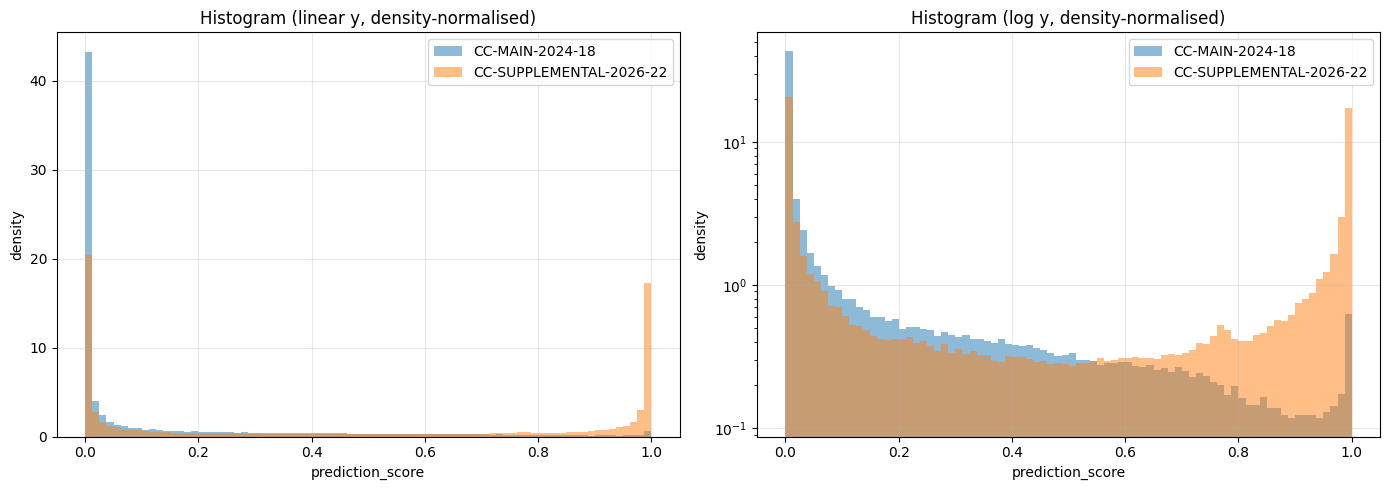

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
bins = np.linspace(0.0, 1.0, 81)

for ax, log_scale in zip(axes, [False, True], strict=True):
    ax.hist(baseline_scores, bins=bins, alpha=0.5, label=BASELINE_NAME, color="C0", density=True)
    ax.hist(focus_scores, bins=bins, alpha=0.5, label=FOCUS_NAME, color="C1", density=True)
    if log_scale:
        ax.set_yscale("log")
        ax.set_title("Histogram (log y, density-normalised)")
    else:
        ax.set_title("Histogram (linear y, density-normalised)")
    ax.set_xlabel(SCORE_COL)
    ax.set_ylabel("density")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3b. Empirical CDF

The ECDF makes small distribution-wide shifts very visible: if one curve lies uniformly above the other, that distribution has **lower** scores at every quantile (because for a given score `x`, more of its mass is `≤ x`). Curves that cross indicate the two distributions differ in **shape**, not just location.

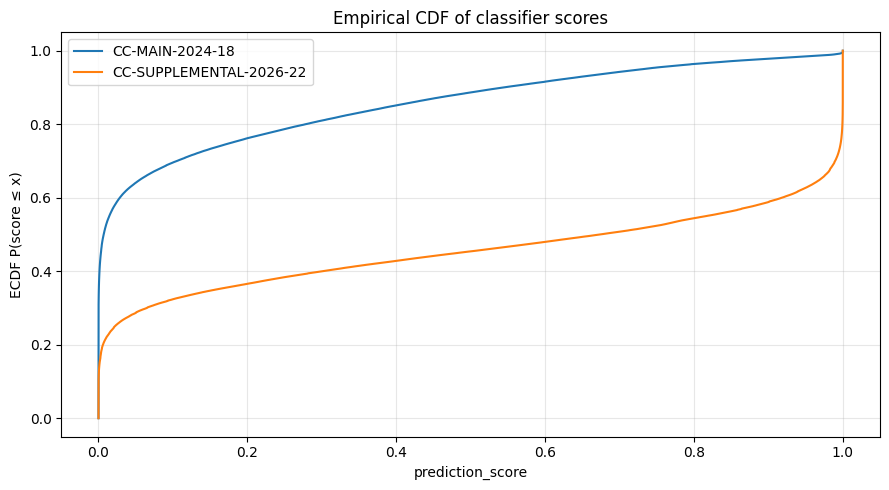

In [5]:
def ecdf(series: pd.Series) -> tuple[np.ndarray, np.ndarray]:
    """Return sorted scores and their corresponding ECDF probabilities."""
    x = np.sort(series.to_numpy())
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y


plt.figure(figsize=(9, 5))
for series, name, color in [
    (baseline_scores, BASELINE_NAME, "C0"),
    (focus_scores, FOCUS_NAME, "C1"),
]:
    x, y = ecdf(series)
    plt.plot(x, y, label=name, color=color)
plt.xlabel(SCORE_COL)
plt.ylabel("ECDF P(score ≤ x)")
plt.title("Empirical CDF of classifier scores")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 3c. Box + violin

Box: median, IQR, whiskers at 1.5 × IQR (outliers hidden because there are millions of them). Violin: full kernel-density estimate of the distribution shape.

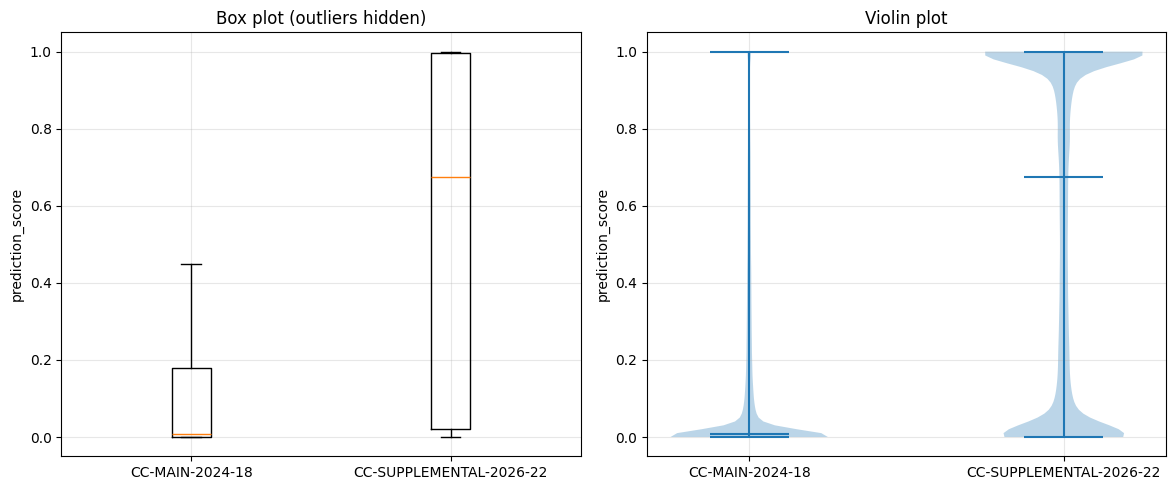

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

data = [baseline_scores, focus_scores]
labels = [BASELINE_NAME, FOCUS_NAME]

axes[0].boxplot(data, tick_labels=labels, showfliers=False)
axes[0].set_ylabel(SCORE_COL)
axes[0].set_title("Box plot (outliers hidden)")
axes[0].grid(True, alpha=0.3)

axes[1].violinplot(data, showmedians=True)
axes[1].set_xticks([1, 2])
axes[1].set_xticklabels(labels)
axes[1].set_ylabel(SCORE_COL)
axes[1].set_title("Violin plot")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3d. Quantile-quantile (Q-Q) plot

If the two distributions are identical the points lie on `y = x`. Systematic deviation above the line means the focus crawl has higher scores at the matching quantile; deviation below means lower.

With samples this large we subsample evenly along the quantile axis to keep the plot readable.

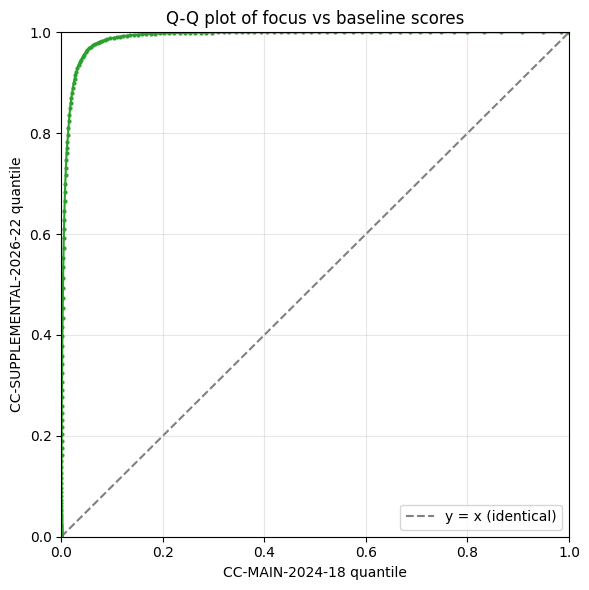

In [7]:
qs = np.linspace(0.001, 0.999, 200)
baseline_q = np.quantile(baseline_scores, qs)
focus_q = np.quantile(focus_scores, qs)

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], color="grey", linestyle="--", label="y = x (identical)")
plt.plot(baseline_q, focus_q, marker=".", linestyle="-", color="C2", markersize=4)
plt.xlabel(f"{BASELINE_NAME} quantile")
plt.ylabel(f"{FOCUS_NAME} quantile")
plt.title("Q-Q plot of focus vs baseline scores")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Significance testing

Classifier-score distributions are heavily right-skewed and non-normal, so we lead with **non-parametric tests** that make no normality assumption. We complement with Welch's t-test (mean difference, robust to unequal variances) for completeness.

1. **Kolmogorov–Smirnov (two-sample)** — asks whether the two distributions differ *anywhere* (location, shape, or tail). Sensitive to any distributional difference. Returns the largest vertical gap between the two ECDFs.
2. **Mann–Whitney U / Wilcoxon rank-sum** — asks whether one distribution stochastically dominates the other; under symmetry this is equivalent to comparing medians.
3. **Welch's t-test** — tests difference in **means** without assuming equal variances.

Caveat: with N in the millions, every test will return a near-zero p-value for almost any real difference. We treat p-values as a sanity check on direction and pair them with effect sizes (next section) for the substantive answer.

In [8]:
ks_result = stats.ks_2samp(baseline_scores, focus_scores, method="auto")
mwu_result = stats.mannwhitneyu(focus_scores, baseline_scores, alternative="two-sided")
t_result = stats.ttest_ind(focus_scores, baseline_scores, equal_var=False)

tests_df = pd.DataFrame(
    {
        "test": ["KS (two-sample)", "Mann-Whitney U", "Welch's t"],
        "statistic": [ks_result.statistic, mwu_result.statistic, t_result.statistic],
        "p_value": [ks_result.pvalue, mwu_result.pvalue, t_result.pvalue],
    }
)
tests_df

,test,statistic,p_value
0,KS (two-sample),4.362318e-01,0.0
1,Mann-Whitney U,7.695199e+11,0.0
2,Welch's t,8.071416e+02,0.0


## 5. Direction and effect size

A p-value tells us **whether** a difference is detectable; effect size tells us **how big** it is.

- **Mean delta / median delta** — the difference in raw score units.
- **Cohen's d** — standardised mean difference, units of pooled SD. Conventional reading: 0.2 = small, 0.5 = medium, 0.8 = large.
- **Common Language Effect Size (CLES)** — `P(focus > baseline)` if we draw one record from each at random. 0.5 means the distributions are identical; > 0.5 means focus scores tend to be higher. Derived directly from the Mann–Whitney U statistic.

In [9]:
def cohens_d(a: pd.Series, b: pd.Series) -> float:
    """Cohen's d for two independent samples (pooled SD denominator)."""
    na, nb = len(a), len(b)
    pooled_var = ((na - 1) * a.var(ddof=1) + (nb - 1) * b.var(ddof=1)) / (na + nb - 2)
    return float((a.mean() - b.mean()) / np.sqrt(pooled_var))


# CLES from Mann-Whitney U: focus is the first arg above, so U_focus / (n_focus * n_baseline)
# is the probability a random focus score exceeds a random baseline score.
cles = float(mwu_result.statistic / (len(focus_scores) * len(baseline_scores)))

effect_df = pd.DataFrame(
    {
        "metric": [
            "mean delta (focus - baseline)",
            "median delta (focus - baseline)",
            "Cohen's d (focus vs baseline)",
            "CLES = P(focus > baseline)",
        ],
        "value": [
            focus_scores.mean() - baseline_scores.mean(),
            focus_scores.median() - baseline_scores.median(),
            cohens_d(focus_scores, baseline_scores),
            cles,
        ],
    }
)
effect_df.round(6)

,metric,value
0,mean delta (focus - baseline),0.403044
1,median delta (focus - baseline),0.666728
2,Cohen's d (focus vs baseline),1.141602
3,CLES = P(focus > baseline),0.769694


## 6. Conclusion

The cell below assembles a one-paragraph verdict from the tests above. Read it together with the effect-size table — large samples make tiny differences look statistically significant, but only effect-size measures tell you whether the difference matters in practice. The verdict also names whether the focus column is real, intermediate (partial crawl), or toy data so you don't accidentally trust an early read.

In [10]:
ALPHA = 0.01  # conservative bar given large N
mean_delta = focus_scores.mean() - baseline_scores.mean()
direction = "higher" if mean_delta > 0 else ("lower" if mean_delta < 0 else "unchanged")
all_significant = all(p < ALPHA for p in [ks_result.pvalue, mwu_result.pvalue, t_result.pvalue])
verdict = (
    "STATISTICALLY SIGNIFICANT under all three tests"
    if all_significant
    else f"NOT all tests significant at alpha={ALPHA}"
)
if is_toy:
    data_qualifier = "TOY focus data (baseline + noise)"
elif is_partial:
    data_qualifier = (
        f"INTERMEDIATE real focus-crawl data "
        f"({len(focus_scores) / len(baseline_scores):.0%} of baseline size)"
    )
else:
    data_qualifier = "real focus-crawl data"

print(
    f"Comparison: {FOCUS_NAME} vs {BASELINE_NAME}  [{data_qualifier}]\n"
    f"  Direction:     focus is {direction} than baseline\n"
    f"  Mean delta:    {mean_delta:+.6f}\n"
    f"  Median delta:  {focus_scores.median() - baseline_scores.median():+.6f}\n"
    f"  Cohen's d:     {cohens_d(focus_scores, baseline_scores):+.3f}\n"
    f"  CLES:          {cles:.3f}  (P(focus > baseline))\n"
    f"  KS p:          {ks_result.pvalue:.3e}\n"
    f"  MWU p:         {mwu_result.pvalue:.3e}\n"
    f"  Welch's t p:   {t_result.pvalue:.3e}\n"
    f"  Verdict:       {verdict}"
)

Comparison: CC-SUPPLEMENTAL-2026-22 vs CC-MAIN-2024-18  [real focus-crawl data]
  Direction:     focus is higher than baseline
  Mean delta:    +0.403044
  Median delta:  +0.666728
  Cohen's d:     +1.142
  CLES:          0.770  (P(focus > baseline))
  KS p:          0.000e+00
  MWU p:         0.000e+00
  Welch's t p:   0.000e+00
  Verdict:       STATISTICALLY SIGNIFICANT under all three tests
